using mkl fft
mkl fft not available trying numpy


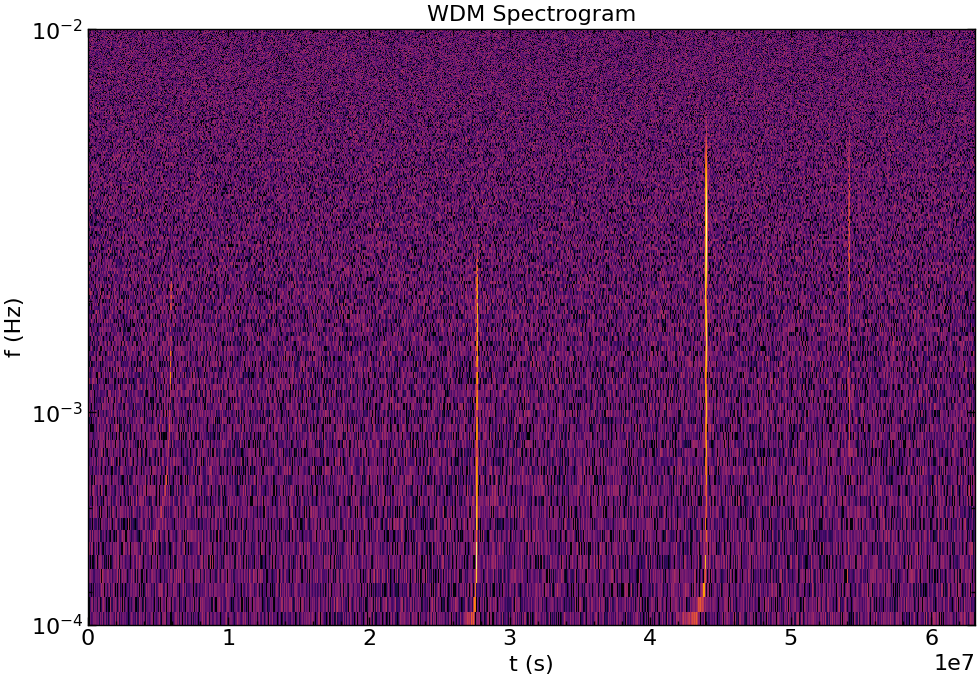

/var/folders/b6/2qbfd6292nscb0n7451jvf0r0000gp/T/ipykernel_67937/677471560.py:271: RuntimeWarning: divide by zero encountered in log10
  aboveNoise = np.where(np.log10(np.abs(indivTimeSeries[i])) >= -22.12 + np.log10(2))[0]
/var/folders/b6/2qbfd6292nscb0n7451jvf0r0000gp/T/ipykernel_67937/677471560.py:271: RuntimeWarning: divide by zero encountered in log10
  aboveNoise = np.where(np.log10(np.abs(indivTimeSeries[i])) >= -22.12 + np.log10(2))[0]
/var/folders/b6/2qbfd6292nscb0n7451jvf0r0000gp/T/ipykernel_67937/677471560.py:271: RuntimeWarning: divide by zero encountered in log10
  aboveNoise = np.where(np.log10(np.abs(indivTimeSeries[i])) >= -22.12 + np.log10(2))[0]
/var/folders/b6/2qbfd6292nscb0n7451jvf0r0000gp/T/ipykernel_67937/677471560.py:271: RuntimeWarning: divide by zero encountered in log10
  aboveNoise = np.where(np.log10(np.abs(indivTimeSeries[i])) >= -22.12 + np.log10(2))[0]


Done. Image → imageDataTest/images/train/single_test_image.jpg
YOLO labels → imageDataTest/labels/train/single_test_image.txt


16369

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import warnings; warnings.simplefilter("always")
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle; mplstyle.use('fast')
from matplotlib import colors
import scienceplots; plt.style.use(["science", "notebook"])
import os; os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"; os.environ["CUDA_VISIBLE_DEVICES"] = ""
from pathlib import Path
from WDMWaveletTransforms.wavelet_transforms import transform_wavelet_freq
from phentax.waveform import IMRPhenomTHM
from lisaconstants import ASTRONOMICAL_YEAR, C, GRAVITATIONAL_CONSTANT, SOLAR_MASS
from lisatools.detector import EqualArmlengthOrbits
from fastlisaresponse import ResponseWrapper
from scipy.signal import welch
import yaml, gc

# ── Helper Functions ──────────────────────────────────────────────────────────

def getWDMMatrix(waveform, Nt=128, Nf=None, noiseLevel=10**(-22.5), noiseLevel2=10**(-27),
                 whitenPSD=None, dt=None, fmin=1e-8, fmax=np.inf):
    if Nf is None:
        Nf = len(waveform) // Nt
    ND = Nf * Nt
    dataFFT = np.fft.fft(waveform[:ND])
    waveletAmplitudeMatrix = transform_wavelet_freq(dataFFT, Nf, Nt).T
    fCoords = np.arange(0, Nf + 1) / (2 * dt * Nf)
    waveletAmplitudeMatrix = np.abs(waveletAmplitudeMatrix)
    if whitenPSD is not None and dt is not None:
        waveletAmplitudeMatrix /= np.sqrt(np.interp(fCoords[1:], whitenPSD[0], whitenPSD[1])[:, np.newaxis])
    elif whitenPSD is not None:
        print('dt missing — whitening skipped.')
    fMaxIdx = Nf if fmax == np.inf else np.abs(fCoords - fmax).argmin()
    fmax    = fCoords[-1] if fmax == np.inf else fmax
    fMinIdx = 0 if fmin == 0 else np.abs(fCoords - fmin).argmin()
    waveletAmplitudeMatrix = waveletAmplitudeMatrix[fMinIdx:fMaxIdx, :]
    waveletAmplitudeMatrix /= waveletAmplitudeMatrix.max()
    minAmp = waveletAmplitudeMatrix.min()
    return np.nan_to_num(waveletAmplitudeMatrix, nan=minAmp, posinf=minAmp, neginf=minAmp), fMinIdx, fMaxIdx


def getSpectrogram(WDMMatrix, Nt, Nf, dt, cmap='inferno', vmin=None, vmax=None,
                   logColor=True, logFreq=True, fmin=1e-8, fmax=np.inf,
                   filename=None, imageFolder=None, showPlot=True, plotFeatures=False):
    Nd   = Nf * Nt
    TObs = Nd * dt
    tCoords = np.linspace(0, TObs, Nt + 1)
    fCoords = np.arange(0, Nf + 1) / (2 * dt * Nf)
    fMaxIdx = Nf if fmax == np.inf else np.abs(fCoords - fmax).argmin()
    fmax    = fCoords[-1] if fmax == np.inf else fmax
    fMinIdx = 0 if fmin == 0 else np.abs(fCoords - fmin).argmin()
    vmin = WDMMatrix.min() + 1e-20 if vmin is None else vmin
    vmax = WDMMatrix.max()         if vmax is None else vmax
    norm = colors.LogNorm(vmin=vmin, vmax=vmax, clip=True) if logColor else colors.Normalize(vmin=vmin, vmax=vmax)
    fig, ax = plt.subplots(figsize=(10, 7))
    plt.pcolormesh(tCoords, fCoords[fMinIdx:fMaxIdx + 1], WDMMatrix,
                   cmap=cmap, shading='auto', snap=False, rasterized=True, norm=norm)
    plt.grid(False)
    if plotFeatures:
        plt.xlabel('t (s)'); plt.ylabel('f (Hz)'); plt.title('WDM Spectrogram')
    else:
        ax.set_axis_off()
        ax.xaxis.set_major_locator(plt.NullLocator())
        ax.yaxis.set_major_locator(plt.NullLocator())
    if logFreq:
        ax.set_yscale('asinh', linear_width=0.0005)
    ax.set_ylim(fmin, fmax)
    plt.tight_layout()
    if showPlot:
        plt.show()
    if filename is not None:
        plt.savefig(Path(imageFolder) / (filename + '.jpg'), dpi=300, pad_inches=0.0)
    plt.close()
    return fig, ax, tCoords, fCoords[fMinIdx:fMaxIdx + 1]


def instantiateResponseFunc(dt, Tobs, allModes=False):
    imr = IMRPhenomTHM(
        higher_modes="all" if allModes else None,
        include_negative_modes=True,
        t_low_fit=True,
        coarse_grain=False,
        atol=1e-12, rtol=1e-12,
        T=Tobs,
    )
    def compute_polarizations(m1, m2, chi1, chi2, distance, phi_ref, inclination, psi, dt, f_min, f_ref, T):
        times, mask, hplus, hcross = imr.compute_polarizations_at_once(
            m1=m1, m2=m2, chi1z=chi1, chi2z=chi2,
            distance=distance, phi_ref=phi_ref,
            inclination=inclination, psi=psi,
            f_min=f_min, f_ref=f_ref, delta_t=dt)
        return hplus[mask] + 1j * hcross[mask]
    return ResponseWrapper(
        waveform_gen=compute_polarizations,
        Tobs=Tobs / ASTRONOMICAL_YEAR,
        dt=dt,
        index_lambda=0, index_beta=1,
        flip_hx=False, remove_sky_coords=True,
        remove_garbage=True, force_backend="cpu",
        orbits=EqualArmlengthOrbits()
    )


def getResponse(logmT, q, chi1, chi2, distance, cosinc, phi_ref, psi,
                f_min, f_ref, sinbeta, lam, dt, Tobs, allModes=False, responseFunc=None):
    if responseFunc is None:
        responseFunc = instantiateResponseFunc(dt, Tobs, allModes=allModes)
    mT = 10**logmT; m1 = mT / (q + 1); m2 = mT - m1
    return responseFunc(
        np.arcsin(sinbeta), lam,
        m1=m1, m2=m2, chi1=chi1, chi2=chi2,
        distance=distance, phi_ref=phi_ref,
        inclination=np.arccos(cosinc), psi=psi,
        dt=dt, f_min=f_min, f_ref=f_ref
    )


def placeXIntoY(x, y, xIdx=0, yIdx=0, add=True, fadeLengthStart=0):
    def halfCosWindow(n):
        return 0.5 * (1 - np.cos(np.linspace(0, np.pi, n)))
    xLen, yLen = len(x), len(y)
    idxDiffStart = yIdx - xIdx
    idxDiffEnd   = (yLen - yIdx) - (xLen - xIdx)
    yStart = 0            if idxDiffStart < 0 else idxDiffStart
    yEnd   = yLen         if idxDiffEnd   < 0 else idxDiffStart + xLen
    xStart = -idxDiffStart if idxDiffStart < 0 else 0
    xEnd   = xLen + idxDiffEnd if idxDiffEnd < 0 else xLen
    xFaded = np.copy(x[xStart:xEnd])
    n = len(xFaded)
    fade = min(fadeLengthStart, n)
    xFaded[:fade] *= halfCosWindow(fadeLengthStart)[:fade]
    xIdxNew = xIdx if idxDiffStart >= 0 else xIdx + idxDiffStart
    xFaded[xIdxNew + 1:] *= halfCosWindow(n - (xIdxNew + 1))[::-1]
    if add: y[yStart:yEnd] += xFaded
    else:   y[yStart:yEnd]  = xFaded
    return y


def TDIPlacement(totTimeSeries, tC, TDIData, dt):
    tCIdx  = int(tC / dt)
    tCData = np.argmax(np.abs(TDIData))
    placeXIntoY(TDIData, totTimeSeries, tCData, tCIdx,
                fadeLengthStart=len(TDIData) // 20)


def getBoundingBox(matrix, tCIdx, leftThreshold, tObsIdxSize, fMinIdx,
                   lineExtension=-1, manualTopBoundaryY=None,
                   manualLeftBoundaryX=None, manualBottomBoundaryY=None,
                   topThreshold=None, logNormalize=True):
    if not isinstance(matrix, np.ndarray):
        matrix = np.array(matrix)
    m = matrix.copy()
    if logNormalize:
        vmin, vmax = 10**(-4), m.max()
        m = np.clip((np.log10(m) - np.log10(vmin)) / (np.log10(vmax) - np.log10(vmin)), 0, 1)
    nRows, nCols = m.shape
    rightBoundary = min(tCIdx, nCols - 1)
    leftExtend  = min(lineExtension, tCIdx)           if lineExtension != -1 else 0
    rightExtend = min(lineExtension, (nCols-1)-tCIdx) if lineExtension != -1 else 0
    leftStart   = max(0, tCIdx - tObsIdxSize)
    topBoundary = bottomBoundary = leftBoundary = -1
    # top boundary
    if manualTopBoundaryY is not None:
        topBoundary = min(manualTopBoundaryY, nRows - 1)
    else:
        for row in reversed(range(nRows)):
            vals = m[row, tCIdx - leftExtend : tCIdx + rightExtend + 1] if lineExtension != -1 else m[row, :]
            if (vals >= topThreshold).any():
                topBoundary = row; break
    # left + bottom boundaries
    if manualLeftBoundaryX is not None and manualBottomBoundaryY is None:
        leftBoundary = manualLeftBoundaryX
        bottomBoundary = fMinIdx + m[fMinIdx:, leftBoundary].argmax()
    elif manualLeftBoundaryX is not None:
        leftBoundary, bottomBoundary = manualLeftBoundaryX, manualBottomBoundaryY
    else:
        for col in range(leftStart, tCIdx):
            valid = np.where(m[fMinIdx:, col] >= leftThreshold)[0]
            if valid.size > 0:
                leftBoundary = col; bottomBoundary = fMinIdx + valid.max(); break
    names = ["Top", "Bottom", "Left"]
    for name, val in zip(names, [topBoundary, bottomBoundary, leftBoundary]):
        if val == -1:
            warnings.warn(f"{name} boundary not found.", UserWarning, stacklevel=2)
    return leftBoundary, rightBoundary, bottomBoundary, topBoundary


def convertToYoloCoords(bboxIndices, tCoords, fCoords, yLimMin, yLimMax, asinhLinearWidth=0.0005):
    leftIdx, rightIdx, bottomIdx, topIdx = bboxIndices
    tMin, tMax = tCoords[0], tCoords[-1]
    xL = (tCoords[leftIdx]  - tMin) / (tMax - tMin)
    xR = (tCoords[rightIdx] - tMin) / (tMax - tMin)
    def A(v): return np.arcsinh(v / asinhLinearWidth)
    sMin, sMax = A(yLimMin), A(yLimMax)
    yB = (A(fCoords[bottomIdx]) - sMin) / (sMax - sMin)
    yT = (A(fCoords[topIdx])    - sMin) / (sMax - sMin)
    xC = np.clip((xL + xR) / 2,       0, 1)
    yC = np.clip(((1-yT) + (1-yB))/2, 0, 1)
    w  = np.clip(xR - xL,             0, 1)
    h  = np.clip((1-yT) - (1-yB),     0, 1)
    return f'0 {xC:.6f} {yC:.6f} {w:.6f} {h:.6f}'


# ── Single-Image Generation ───────────────────────────────────────────────────

dt      = 2.5
TObs    = 5 * ASTRONOMICAL_YEAR / 12
TObsTot = 2 * ASTRONOMICAL_YEAR
fmin, fmax = 1e-4, 1e-2
vmin, vmax = 10**(-4), 2e-1
waveletDuration = 3600 * 3
topThresh, leftThresh = 0.5, 0.1
imageFolder = Path("imageDataTest/images/train")
imageFolder.mkdir(parents=True, exist_ok=True)
(Path("imageDataTest/labels/train")).mkdir(parents=True, exist_ok=True)
(Path("imageDataTest/params/train")).mkdir(parents=True, exist_ok=True)
filename = "single_test_image"

rng     = np.random.default_rng(42)           # seed for reproducibility; remove for random
numBHBs = rng.integers(4, 5, endpoint=True)   # 1–3 sources for a quick test
tCs     = rng.uniform(0, TObsTot, numBHBs)

paramNames  = ['logmT','q','chi1','chi2','distance','cosinc','phi_ref','psi','f_min','f_ref','sinbeta','lam']
paramRanges = [[5.5,7],[0.1,0.99999],[-0.9999999,0.9999999],[-0.9999999,0.9999999],
               [5e2,1e3],[-1,1],[0,2*np.pi],[0,2*np.pi],[1e-8,1e-8],[1e-8,1e-8],[-1,1],[0,2*np.pi]]
randomArgsDict = {n: rng.uniform(r[0], r[1], numBHBs) for n, r in zip(paramNames, paramRanges)}
randomArgsDict['tC'] = tCs

responseFunc = instantiateResponseFunc(dt=dt, Tobs=TObs)

waveforms = []
for i in range(numBHBs):
    args = {n: randomArgsDict[n][i] for n in paramNames}
    waveforms.append(getResponse(**args, dt=dt, Tobs=TObs, responseFunc=responseFunc))

numTotTimes   = int(TObsTot / dt)
totTimeSeries = np.zeros(numTotTimes)
indivTimeSeries = np.zeros((numBHBs, numTotTimes))
for i, wf in enumerate(waveforms):
    TDIPlacement(totTimeSeries,      tCs[i], wf[0], dt)
    TDIPlacement(indivTimeSeries[i], tCs[i], wf[0], dt)

# Add noise
noise = np.clip(rng.normal(0, 1, numTotTimes), -2.5, 2.5)
totTimeSeries += 10**(-20.2) * noise

# WDM matrices
nT = int(TObsTot / waveletDuration)
nD = len(totTimeSeries)
nF = int(nD / nT)
nF -= nF % 2; nT -= nT % 2; nD = nF * nT

masterWDM, absFMinIdx, _ = getWDMMatrix(totTimeSeries, nT, nF, fmin=fmin, fmax=fmax, dt=dt)
WDMs = [getWDMMatrix(ts, nT, nF, fmin=fmin, fmax=fmax, dt=dt)[0] for ts in indivTimeSeries]

# Plot + save
fig, ax, tCoords, fCoords = getSpectrogram(
    masterWDM, nT, nF, dt,
    vmin=vmin, vmax=vmax, fmin=fmin, fmax=fmax,
    showPlot=True, filename=filename, imageFolder=imageFolder,
    plotFeatures=True, cmap='inferno'
)

# Bounding boxes + YOLO label
BBoxes = []
fCoordSpacing = 1 / waveletDuration / 2
for i, WDM in enumerate(WDMs):
    mT = 10**randomArgsDict['logmT'][i]
    m1 = mT / (randomArgsDict['q'][i] + 1); m2 = mT - m1
    aboveNoise = np.where(np.log10(np.abs(indivTimeSeries[i])) >= -22.12 + np.log10(2))[0]
    if len(aboveNoise) == 0:
        leftIdxWDM = fBottomGWIdx = None
    else:
        leftIdx    = aboveNoise.min()
        actualTime = leftIdx * dt
        leftIdxWDM = int(np.ceil(actualTime / waveletDuration))
        betaParam  = 64 * GRAVITATIONAL_CONSTANT**3 * (m1*SOLAR_MASS) * (m2*SOLAR_MASS) * SOLAR_MASS * (m1+m2) / (5 * C**5)
        T_c        = tCs[i] - actualTime
        a0         = (4 * betaParam * T_c)**(1/4)
        fBottomGW  = 2 / np.sqrt(4 * np.pi**2 * a0**3 / (GRAVITATIONAL_CONSTANT * mT * SOLAR_MASS))
        fBottomGWIdx = max(0, min(int(np.ceil(fBottomGW / fCoordSpacing)) - absFMinIdx, WDM.shape[0]-1))
    BBoxes.append(getBoundingBox(
        WDM, round(tCs[i] / waveletDuration) + 5,
        topThreshold=topThresh, leftThreshold=leftThresh,
        tObsIdxSize=int(TObs / waveletDuration), fMinIdx=0,
        logNormalize=True, manualLeftBoundaryX=leftIdxWDM,
        manualBottomBoundaryY=fBottomGWIdx
    ))

labelFile = Path("imageDataTest/labels/train") / (filename + ".txt")
with labelFile.open('w') as f:
    lines = [convertToYoloCoords(bb, tCoords, fCoords, fmin, fmax) for bb in BBoxes]
    f.write('\n'.join(lines))

# Save params
with (Path("imageDataTest/params/train") / (filename + ".yaml")).open('w') as f:
    yaml.dump({k: v.tolist() if isinstance(v, np.ndarray) else v
               for k, v in randomArgsDict.items()}, f)

print(f"Done. Image → {imageFolder}/{filename}.jpg")
print(f"YOLO labels → {labelFile}")
gc.collect()

In [59]:
import numpy as np
from fastlisaresponse.utils.parallelbase import ParallelModuleBase

# seconds in a year
YRSID_SI = 31558149.763545603
G = 6.67430e-11
c = 299792458.0
Msun_SI = 1.9884099022586536e30
Mpc_to_m =  3.0856776e22

class WDWave(ParallelModuleBase):
    def __init__(self, force_backend=None):
        super().__init__(force_backend=force_backend)

    def __call__(
        self,
        *, # necessary to specify f = .., fdot = ....
        f,
        fdot=0.0,
        iota,
        psi,
        phi0,
        A=None, # can pass either A OR masses AND distance
        m1=None,
        m2=None,
        distance=None,
        T=1.0,
        dt=10.0,

        # --- plotting options ---
        plot=False,
        plot_xlim=None,   # e.g. (tmin, tmax) in years, or None
    ):
        t = self.xp.arange(0.0, T * YRSID_SI, dt)

        cos2psi = self.xp.cos(2.0 * psi)
        sin2psi = self.xp.sin(2.0 * psi)
        cosiota = self.xp.cos(iota)

        fddot = 11.0 / 3.0 * fdot**2 / f

        phase = (2.0 * np.pi * ( f * t  + (1.0/2.0) * fdot * t**2  + (1.0 / 6.0) * fddot * t**3)- phi0)

        if A is None:
            if m1 is None or m2 is None or distance is None:
                raise ValueError("Provide either A or both masses AND distance.")

            Mchirp = (m1*m2)**(3/5)/(m1+m2)**(1/5)
            M_SI = Mchirp * Msun_SI
            D = distance * Mpc_to_m

            A_use = 8 / (5**(1/2)) * (G * M_SI / (c**2) / D) * (np.pi * G * M_SI * f / (c**3))**(2/3)
        else:
            A_use = A

        hSp = -self.xp.cos(phase) * A_use * (1.0 + cosiota * cosiota)
        hSc = -self.xp.sin(phase) * 2.0 * A_use * cosiota

        hp = hSp * cos2psi - hSc * sin2psi
        hc = hSp * sin2psi + hSc * cos2psi

        h_complex = hp + 1j * hc

        hp_np = np.asarray(hp)
        hc_np = np.asarray(hc)
        
        # print("hp min/max:", hp_np.min(), hp_np.max())
        # print("hc min/max:", hc_np.min(), hc_np.max())
        # print("hp mean abs diff:", np.mean(np.abs(np.diff(hp_np))))
        # print("hc mean abs diff:", np.mean(np.abs(np.diff(hc_np))))
        
        if plot:
            import matplotlib.pyplot as plt
        
            t_years = (self.xp.asarray(t) / YRSID_SI)
            hp_np = np.asarray(hp)
            hc_np = np.asarray(hc)
            hmag_np = np.asarray(self.xp.abs(h_complex))
        
            # Downsample for visualization only
            n = len(t_years)
            target_points = 5000
            plot_skip = max(1, n // target_points)
            sl = slice(0, n, plot_skip)
        
            fig, ax = plt.subplots(3, 1, sharex=True, figsize=(10, 7))
            ax[0].plot(t_years[sl], hp_np[sl], lw=1)
            ax[0].set_ylabel(r"$h_+(t)$")
        
            ax[1].plot(t_years[sl], hc_np[sl], lw=1)
            ax[1].set_ylabel(r"$h_\times(t)$")
        
            ax[2].plot(t_years[sl], hmag_np[sl], lw=1)
            ax[2].set_ylabel(r"$|h(t)|$")
            ax[2].set_xlabel("Time [years]")
        
            if plot_xlim is not None:
                ax[2].set_xlim(plot_xlim)
        
            plt.tight_layout()

        return h_complex

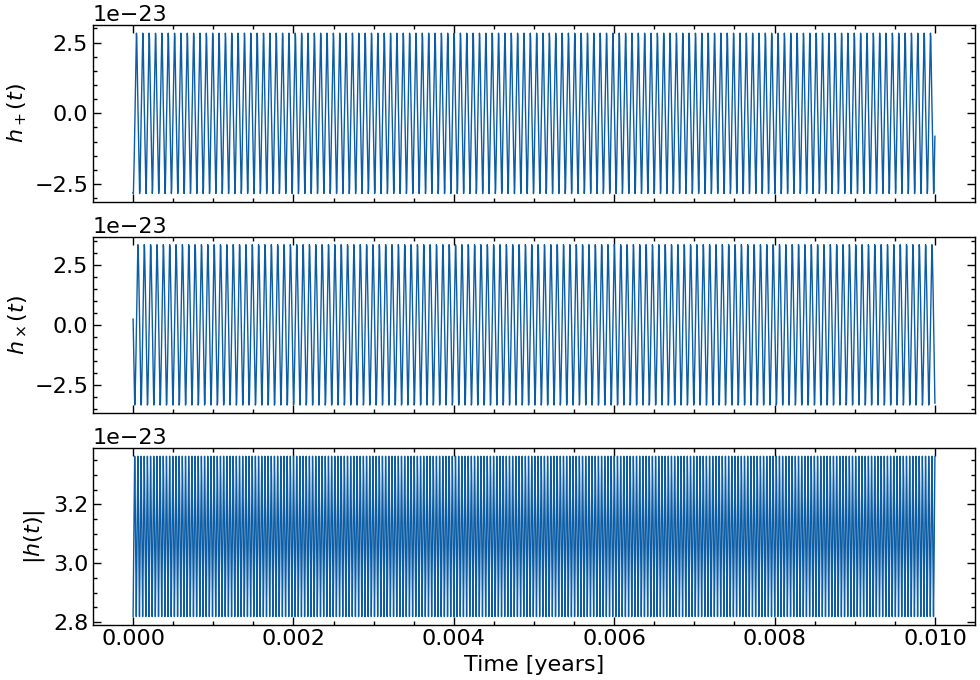

In [64]:
gb = WDWave(force_backend='fastlisaresponse_cpu')

h = gb(
    f=4e-4,
    fdot=1e-19,
    iota=1.0,
    psi=0.7,
    phi0=1.5,
    m1 = 0.25,
    m2 = 0.49,
    distance=3e-3,
    T=0.01,
    dt=2.5,   # if your dt is tied to a sampling frequency like before
    plot=True,
)

In [4]:
from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisaconstants import ASTRONOMICAL_YEAR

def instantiateWDResponseWrapper(Tobs_years, dt, gb, index_lambda=0, index_beta=1, t0=0.0):
    orbits = EqualArmlengthOrbits()

    responseWrapper = ResponseWrapper(
        gb,
        Tobs_years,
        dt,
        index_lambda,
        index_beta,
        t0=t0,
        flip_hx=False,
        force_backend="cpu",
        remove_sky_coords=True,
        is_ecliptic_latitude=True,
        orbits=orbits,

        order=25,
        tdi="2nd generation",
        tdi_chan="AET",
    )
    return responseWrapper

In [67]:
import time

t0 = time.perf_counter()

Tobs_years = 2 #TObs / ASTRONOMICAL_YEAR   # if TObs is in seconds in your code
dt = 2.5
beta = 0.9805742971871619
lam = 5.22979888

responseWrapper = instantiateWDResponseWrapper(
    Tobs_years=Tobs_years,
    dt=dt,
    gb=gb,
    t0=0.0,
)

f_gw = 3e-3
fdot = 1e-20
iota = 1.0
psi = 0.7
phi0 = 1.5

m1 = 0.5
m2 = 0.6
distance = 1e20

waveA, waveE, waveT = responseWrapper(
    lam, beta,
    f=f_gw,
    fdot=fdot,
    iota=iota,
    psi=psi,
    phi0=phi0,
    m1=m1,
    m2=m2,
    distance=distance,
)
elapsed = time.perf_counter() - t0
print(f"responseWrapper call took {elapsed:.3f} s")

responseWrapper call took 34.711 s


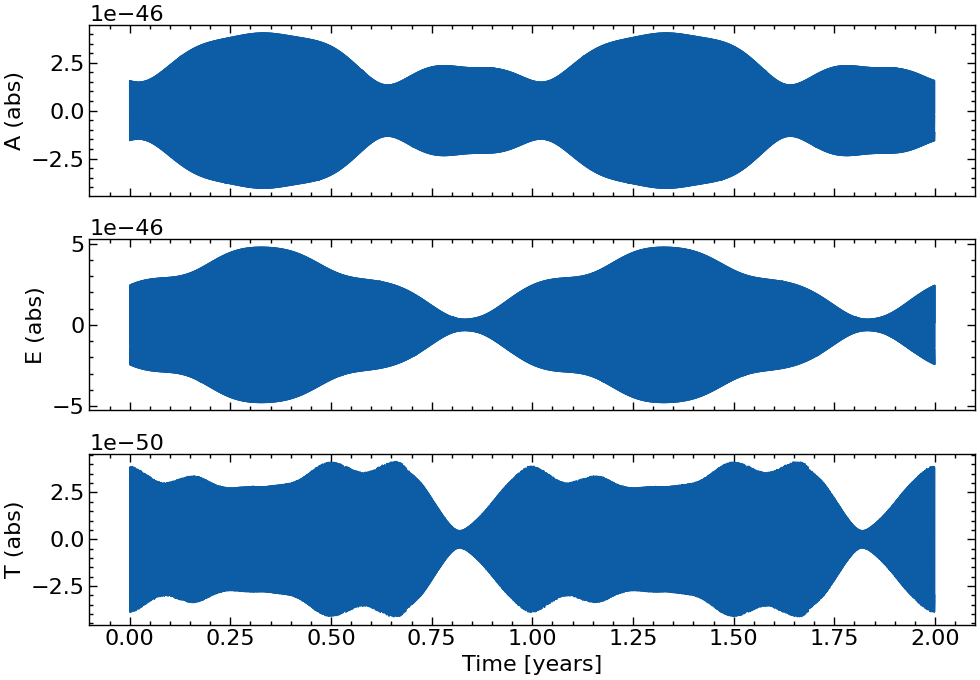

In [6]:
import numpy as np
import matplotlib.pyplot as plt

t_years = np.arange(len(waveA)) * dt / YRSID_SI

fig, ax = plt.subplots(3, 1, sharex=True, figsize=(10, 7))

ax[0].plot(t_years, np.real(waveA), lw=1)
ax[0].set_ylabel("A (abs)")

ax[1].plot(t_years, np.real(waveE), lw=1)
ax[1].set_ylabel("E (abs)")

ax[2].plot(t_years, np.real(waveT), lw=1)
ax[2].set_ylabel("T (abs)")
ax[2].set_xlabel("Time [years]")

plt.tight_layout()
plt.show()

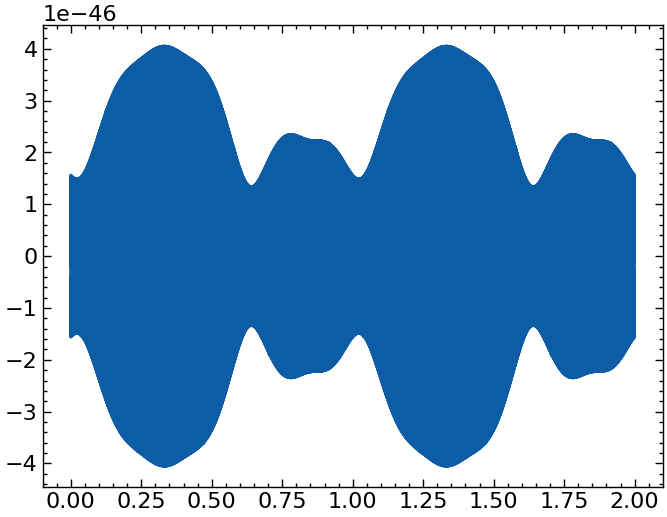

In [7]:
t_years = np.arange(len(waveA)) * dt / YRSID_SI
plt.plot(t_years, np.real(waveA))

In [15]:
def getWDBoundingBox(indivWDM, freq, absFMinIdx, waveletDuration,
                     verticalPadding, wdbIdx=None):
    """
    Build a bounding box for a single white dwarf binary.

    The box spans the entire time axis (full observation) and is centered on
    the WD's known frequency, padded by `verticalPadding` rows on each side.

    indivWDM (2d array): WDM matrix for THIS WDB alone (same grid as master).
    freq (float): the WD's gravitational-wave frequency (Hz).
    absFMinIdx (int): row-offset returned by getWDMMatrix (matrix starts at fmin).
    waveletDuration (float): used to compute row frequency resolution.
    verticalPadding (int): rows to pad above and below the center frequency.
    wdbIdx (int, optional): index for clearer logging.

    Returns (left, right, bottom, top) matching getBoundingBox's convention.
    """
    label = f"WDB {wdbIdx}" if wdbIdx is not None else "WDB"

    m = np.asarray(indivWDM)
    nRows, nCols = m.shape

    # frequency -> row index (same convention as the merger code)
    fCoordSpacing = 1 / waveletDuration / 2
    centerRow_absolute = int(np.ceil(freq / fCoordSpacing))
    centerRow = centerRow_absolute - absFMinIdx
    centerRow = max(0, min(centerRow, nRows - 1))

    # padded band, full time span
    left = 0
    right = nCols - 1
    top = min(centerRow + verticalPadding, nRows - 1)
    bottom = max(centerRow - verticalPadding, 0)

    print(f"[DRAW] {label} at f={freq:.6e} Hz (row {centerRow}, "
          f"rows {bottom}-{top}).")

    return left, right, bottom, top

In [62]:
def getWDResponse(f, fdot, iota, psi, phi0, lam, beta, dt, Tobs,
A=None, m1=None, m2=None, distance=None,
responseWrapper=None, gb=None):

    Tobs_years = Tobs / ASTRONOMICAL_YEAR

    if gb is None:
        gb = WDWave(force_backend="cpu")
    
    if responseWrapper is None:
        responseWrapper = instantiateWDResponseWrapper(Tobs_years, dt, gb)
    
    waveA, waveE, waveT = responseWrapper(
        beta,
        lam,
        f=f,
        fdot=fdot,
        iota=iota,
        psi=psi,
        phi0=phi0,
        A=A,
        m1=m1,
        m2=m2,
        distance=distance,
        T=Tobs_years,
        dt=dt,
    )
    
    return waveA, waveE, waveT

def makeWDTrainingImage(
    numWDBsRange=[3, 4],
    frange=[1e-4, 1e-2],
    fdotRange=[0.0, 1e-16],
    iotaRange=[0, np.pi],
    psiRange=[0, 2 * np.pi],
    phi0Range=[0, 2 * np.pi],
    m1Range=[0.8,1.5],
    m2Range = [0.8,1.5],
    logdistanceRange = [-4,-3], # need to fill this in
    sinbetaRange=[-1.0,1.0],
    lambdaRange=[0.0, 2 * np.pi],
    # Observation parameters
    dt=2.5,
    TObsTot=2 * ASTRONOMICAL_YEAR,
    waveletDuration=3600 * 3,
    # Image/output parameters
    filename='WDM_WDB_Image',
    imageFolder=Path('imageData') / 'images' / 'train',
    showPlot=True,
    vmin=1e-4,
    vmax=None,
    fmin=1e-4,
    fmax=1e-2,
    cmap='inferno',
    noiseLevel=10**(-20.2),
    gb=None,
    responseWrapper=None,
    ):
    
    rng = np.random.default_rng()
    # generate random parameters
    numWDBs = rng.integers(numWDBsRange[0], numWDBsRange[1], endpoint=True)
    
    randomArgsDict = {}
    rangesList = [frange,fdotRange,iotaRange,psiRange,phi0Range,m1Range,m2Range,logdistanceRange,sinbetaRange,lambdaRange]
    randomParamsList = ['f', 'fdot', 'iota', 'psi', 'phi0', 'm1','m2','logdistance','sinbeta','lam']
    for i, param in enumerate(randomParamsList):
        randomArgsDict[param] = rng.uniform(rangesList[i][0],rangesList[i][1],numWDBs)
        
    if gb is None:
        gb = WDWave(force_backend="cpu")
    
    Tobs_years = TObsTot / ASTRONOMICAL_YEAR
    if responseWrapper is None:
        responseWrapper = instantiateWDResponseWrapper(Tobs_years, dt, gb)
        
    numTotTimes = int(TObsTot / dt)
    totTimeSeries = np.zeros(numTotTimes)
    indivTimeSeries = []

    randomArgsDict['distance'] = 10**(randomArgsDict['logdistance'])
    randomArgsDict['beta'] = np.arcsin(randomArgsDict['sinbeta'])
        
    for freq in randomArgsDict['f']:
        print(freq)
    for d in randomArgsDict['distance']:
        print(d)
    
    for i in range(numWDBs):
        try:
            waveA, waveE, waveT = getWDResponse(
                f=randomArgsDict['f'][i],
                fdot=randomArgsDict['fdot'][i],
                iota=randomArgsDict['iota'][i],
                psi=randomArgsDict['psi'][i],
                phi0=randomArgsDict['phi0'][i],
                lam=randomArgsDict['lam'][i],
                beta=randomArgsDict['beta'][i],
                dt=dt,
                Tobs=TObsTot,
                m1 = randomArgsDict['m1'][i],
                m2 = randomArgsDict['m2'][i],
                distance = randomArgsDict['distance'][i],
                responseWrapper=responseWrapper,
                gb=gb,
            )
        
            waveA_real = np.real(waveA)
    
            # pad in case there is mismatch in times
            if len(waveA_real) > numTotTimes:
                waveA_real = waveA_real[:numTotTimes]
            elif len(waveA_real) < numTotTimes:
                waveA_real = np.pad(waveA_real, (0, numTotTimes - len(waveA_real)))
            
            totTimeSeries += waveA_real
            indivTimeSeries.append(waveA_real)
    
        # except block graciously added by Claude
        except Exception as e:
            print(f"WDB {idx} failed: {e}")
            traceback.print_exc()
            indivTimeSeries.append(np.zeros(numTotTimes))
    
    
    noise1 = np.clip(rng.normal(0.0, 1.0, numTotTimes), -2.5, 2.5)
    totTimeSeries += noiseLevel * (noise1)
    
    # make all WDM matrices
    
    nT = int(TObsTot / waveletDuration)
    nD = len(totTimeSeries)
    nF = int(nD / nT)
    
    # Force even
    if nF % 2 != 0:
        nF -= 1
    if nT % 2 != 0:
        nT -= 1
    nD = nF * nT
    
    masterWDM, absFMinIdx, _ = getWDMMatrix(
        totTimeSeries, nT, nF,
        fmin=fmin, fmax=fmax, dt=dt
    )

    
    # Step 6: Generate the spectrogram image ----------------------------------------------
    
    fig, ax, tCoords, fCoords = getSpectrogram( # changed fig, ax
        masterWDM, nT, nF, dt,
        vmin=vmin, vmax=vmax,
        fmin=fmin, fmax=fmax,
        showPlot=True,
        filename=filename,
        imageFolder=imageFolder,
        cmap=cmap,
    )

    BBoxes = []
    drawnFreqs = []

    for idx in range(numWDBs):
        indivWDM, indivFMinIdx, _ = getWDMMatrix(
            indivTimeSeries[idx], nT, nF,
            fmin=fmin, fmax=fmax, dt=dt
        )

        freq = randomArgsDict['f'][idx]
        box = getWDBoundingBox(
            indivWDM,
            freq=freq,
            absFMinIdx=indivFMinIdx,
            waveletDuration=waveletDuration,
            verticalPadding=3,
            wdbIdx=idx,
        )

        BBoxes.append(box)
        drawnFreqs.append(freq)

    # --- summary ---
    print("\n===== WDB bounding box summary =====")
    print(f"Total WDBs: {numWDBs} | Drawn: {len(drawnFreqs)}")
    print("Drawn frequencies (Hz): "
          + ", ".join(f"{f:.6e}" for f in drawnFreqs))
    print("====================================\n")
    
    
    # # Step 7: Save parameters to YAML -----------------------------------------------------
    
    # if filename is not None:
    #     yamlDict = {}
    #     for key, val in randomArgsDict.items():
    #         if isinstance(val, np.ndarray):
    #             yamlDict[key] = val.tolist()
    #         else:
    #             yamlDict[key] = val
        
    #     testTrainVal = Path(imageFolder).name
    #     outPath = Path(imageFolder).parent.parent / "params" / testTrainVal / (filename + ".yaml")
    #     outPath.parent.mkdir(parents=True, exist_ok=True)
        
    #     with outPath.open(mode='w') as file:
    #         yaml.dump(data=yamlDict, stream=file, default_flow_style=False)
    
    
    return masterWDM, totTimeSeries, indivTimeSeries, randomArgsDict

0.0052634298268112705
0.004806491385896725
0.007632510232028168
0.0002688472726821661
0.0007154592713847578
0.0004477248251886379


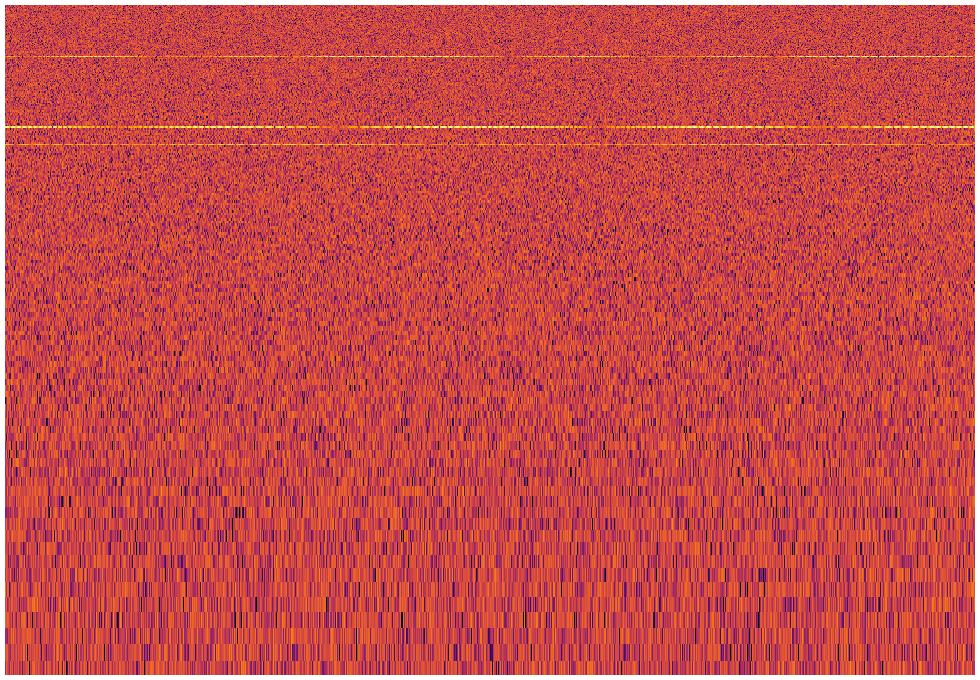

[DRAW] WDB 0 at f=5.263430e-03 Hz (row 112, rows 109-115).
[DRAW] WDB 1 at f=4.806491e-03 Hz (row 102, rows 99-105).
[DRAW] WDB 2 at f=7.632510e-03 Hz (row 163, rows 160-166).

===== WDB bounding box summary =====
Total WDBs: 3 | Drawn: 3
Drawn frequencies (Hz): 5.263430e-03, 4.806491e-03, 7.632510e-03



In [63]:
gb = WDWave(force_backend="fastlisaresponse_cpu")

dt = 2.5
TObsTot = 2 * ASTRONOMICAL_YEAR
Tobs_years = TObsTot / ASTRONOMICAL_YEAR

responseWrapper = instantiateWDResponseWrapper(Tobs_years, dt, gb)

masterWDM, totTimeSeries, indivTimeSeries, params = makeWDTrainingImage(
    gb=gb,
    responseWrapper=responseWrapper,
    dt=dt,
    TObsTot=TObsTot,
    showPlot=True,
)